# Home Assignment 3 — Task 3: Sleep Well

Sleep-stage classification from the (16-dimensional) intermediate U-Time representation of a single EEG channel (Sleep-EDF-15).
This notebook reproduces **all** numbers and figures used in Section 3 of the report.

Run all cells top to bottom. Results are written to `results.json` and figures to `figures/`.

In [ ]:
import json, time, os, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import confusion_matrix

PLOTS_DIR = "plots"
RNG_SEED = 42

if not os.path.exists(PLOTS_DIR):
    os.makedirs(PLOTS_DIR)

np.random.seed(RNG_SEED)

## 3.1 Data understanding and preprocessing

In [ ]:
# The CSV files have no header row and the labels are stored as floats -> header=None, cast to int.
DATA = "data"
X_train = pd.read_csv(f"{DATA}/X_train.csv", header=None).to_numpy()
y_train = pd.read_csv(f"{DATA}/y_train.csv", header=None).to_numpy().ravel().astype(int)
X_test  = pd.read_csv(f"{DATA}/X_test.csv",  header=None).to_numpy()
y_test  = pd.read_csv(f"{DATA}/y_test.csv",  header=None).to_numpy().ravel().astype(int)

print("X_train", X_train.shape, " y_train", y_train.shape)
print("X_test ", X_test.shape,  " y_test ", y_test.shape)
print("NaNs:", np.isnan(X_train).sum() + np.isnan(X_test).sum())
print("Labels:", np.unique(y_train), np.unique(y_test))

RESULTS["shapes"] = dict(n_train=int(X_train.shape[0]), n_test=int(X_test.shape[0]), n_features=int(X_train.shape[1]))

X_train (33724, 16)
y_train (33724,)
X_test  (13901, 16)
y_test  (13901,)
Labels: [0. 1. 2. 3. 4.]


In [32]:
K = 5
counts_train = np.bincount(y_train, minlength=K)
freq_train = counts_train / counts_train.sum()

freq_df = pd.DataFrame({"class": range(K),
                        "count_train": counts_train, "freq_train": freq_train.round(4),
                        "count_test": counts_test,   "freq_test": freq_test.round(4)})
print(freq_df.to_string(index=False))

RESULTS["class_counts_train"] = counts_train.tolist()
RESULTS["class_freq_train"]   = freq_train.tolist()
RESULTS["class_counts_test"]  = counts_test.tolist()
RESULTS["class_freq_test"]    = freq_test.tolist()
# Error of the trivial majority-class predictor: a useful reference for all models below
RESULTS["majority_baseline_train_err"] = float(1 - freq_train.max())
RESULTS["majority_baseline_test_err"]  = float(1 - (y_test == np.argmax(counts_train)).mean())
print("\nMajority-class baseline 0-1 error  train: %.4f   test: %.4f" %
      (RESULTS["majority_baseline_train_err"], RESULTS["majority_baseline_test_err"]))

TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

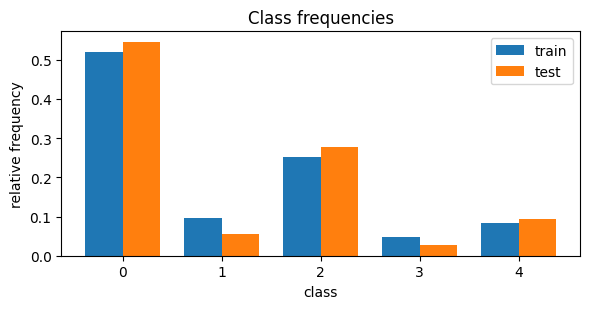

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.2))
w = 0.38; xs = np.arange(K)
ax.bar(xs - w/2, freq_train, w, label="train")
ax.bar(xs + w/2, freq_test,  w, label="test")
ax.set_xticks(xs); ax.set_xlabel("class"); ax.set_ylabel("relative frequency"); ax.legend()
ax.set_title("Class frequencies")
plt.tight_layout(); plt.savefig("figures/class_freq.pdf"); plt.savefig("figures/class_freq.png", dpi=200); plt.show()

### Are the rows i.i.d.? (this determines a valid cross-validation scheme)

The samples are consecutive 30 s epochs of whole-night recordings, so neighbouring rows are probably strongly dependent.
If so, *shuffled* K-fold CV would place near-duplicate epochs in both training and validation folds and give over-optimistic
validation errors. We check this quantitatively.

In [ ]:
same_next = float((y_train[1:] == y_train[:-1]).mean())
same_iid  = float((freq_train ** 2).sum())        # P(y_i = y_j) for two independent draws
lag1 = float(np.mean([np.corrcoef(X_train[1:, j], X_train[:-1, j])[0, 1] for j in range(X_train.shape[1])]))
print(f"P(y_i == y_(i+1)) in file order : {same_next:.4f}")
print(f"same quantity if rows were i.i.d.: {same_iid:.4f}")
print(f"mean lag-1 autocorrelation of features: {lag1:.3f}")
RESULTS["temporal"] = dict(p_same_next=same_next, p_same_iid=same_iid, lag1_feature_autocorr=lag1)

P(y_i == y_(i+1)) in file order : 0.9226
same quantity if rows were i.i.d.: 0.3536
mean lag-1 autocorrelation of features: 0.883


**Conclusion:** rows are in temporal order and strongly dependent. We therefore use **contiguous (un-shuffled) K-fold CV**
(`KFold(shuffle=False)`) for model selection: each validation fold is one block of consecutive epochs, so almost none of a
validation epoch's temporal neighbours are in the training folds. Features are already roughly standardised
(per-feature std between 0.66 and 1.32), so we do **not** rescale them; this is stated in the report.

In [ ]:
print("per-feature std  min/max: %.3f / %.3f" % (X_train.std(0).min(), X_train.std(0).max()))
print("per-feature mean min/max: %.3f / %.3f" % (X_train.mean(0).min(), X_train.mean(0).max()))
RESULTS["feature_scale"] = dict(std_min=float(X_train.std(0).min()), std_max=float(X_train.std(0).max()),
                                mean_min=float(X_train.mean(0).min()), mean_max=float(X_train.mean(0).max()))

def zero_one(model, X, y):
    # 0-1 loss = fraction of misclassified points
    return float(np.mean(model.predict(X) != y))

N_FOLDS = 5
cv_contig = KFold(n_splits=N_FOLDS, shuffle=False)
cv_shuffl = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG_SEED)

per-feature std  min/max: 0.658 / 1.323
per-feature mean min/max: -0.313 / 0.681


## 3.2.1 Multinomial logistic regression

`sklearn.linear_model.LogisticRegression` (multinomial/softmax model, lbfgs solver). We compare
* an (effectively) **unregularised** model (`C = 1e10`), and
* an **L2-regularised** model, $\mathcal{L}(\mathbf{w}) + \lambda\|\mathbf{w}\|^2$ with `C` $\propto 1/\lambda$, where `C` is picked by contiguous 5-fold CV over a log grid.

The 0-1 CV error is used for selection, since 0-1 loss is what we report.

In [ ]:
C_grid = np.logspace(-4, 3, 15)
lr_cv = []
for C in C_grid:
    m = LogisticRegression(C=C, max_iter=5000)
    errs = 1 - cross_val_score(m, X_train, y_train, cv=cv_contig, scoring="accuracy")
    lr_cv.append((C, errs.mean(), errs.std()))
lr_cv = pd.DataFrame(lr_cv, columns=["C", "cv_err", "cv_std"])
print(lr_cv.to_string(index=False))
best_C = float(lr_cv.loc[lr_cv.cv_err.idxmin(), "C"])
print("\nbest C:", best_C)

          C   cv_err   cv_std
   0.000100 0.185890 0.040864
   0.000316 0.172428 0.045039
   0.001000 0.162791 0.036588
   0.003162 0.161723 0.036115
   0.010000 0.161279 0.036119
   0.031623 0.161457 0.036053
   0.100000 0.162168 0.036028
   0.316228 0.161931 0.036223
   1.000000 0.161338 0.035752
   3.162278 0.161427 0.036105
  10.000000 0.160893 0.036204
  31.622777 0.161338 0.035921
 100.000000 0.161012 0.035962
 316.227766 0.161071 0.035963
1000.000000 0.160982 0.035894

best C: 10.0


In [ ]:
lr_unreg = LogisticRegression(C=1e10, max_iter=5000).fit(X_train, y_train)
lr_reg   = LogisticRegression(C=best_C, max_iter=5000).fit(X_train, y_train)

lr_res = {}
for name, m in [("unregularised", lr_unreg), ("l2_cv", lr_reg)]:
    lr_res[name] = dict(train_err=zero_one(m, X_train, y_train), test_err=zero_one(m, X_test, y_test))
    print(f"{name:15s} train err = {lr_res[name]['train_err']:.4f}   test err = {lr_res[name]['test_err']:.4f}")
lr_res["l2_cv"]["C"] = best_C
lr_res["l2_cv"]["cv_err"] = float(lr_cv.cv_err.min())
lr_res["unregularised"]["n_iter"] = int(lr_unreg.n_iter_[0])
RESULTS["logreg"] = lr_res
RESULTS["logreg_cv_curve"] = lr_cv.to_dict(orient="list")

unregularised   train err = 0.1495   test err = 0.0997
l2_cv           train err = 0.1494   test err = 0.0997


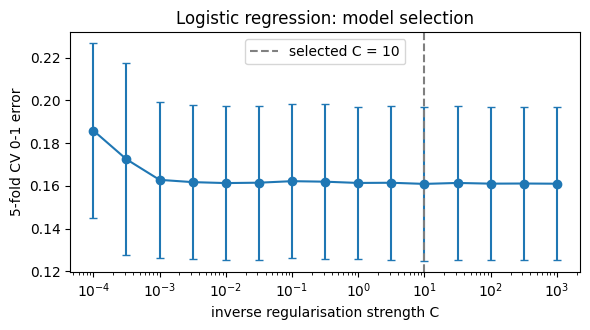

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.errorbar(lr_cv.C, lr_cv.cv_err, yerr=lr_cv.cv_std, marker="o", capsize=3)
ax.axvline(best_C, ls="--", c="gray", label=f"selected C = {best_C:.3g}")
ax.set_xscale("log"); ax.set_xlabel("inverse regularisation strength C"); ax.set_ylabel("5-fold CV 0-1 error")
ax.set_title("Logistic regression: model selection"); ax.legend()
plt.tight_layout(); plt.savefig("figures/logreg_cv.pdf"); plt.savefig("figures/logreg_cv.png", dpi=200); plt.show()

## 3.2.2 Random forest

`sklearn.ensemble.RandomForestClassifier` with `n_estimators` in {50, 100, 200}, Gini impurity, bootstrap sampling,
`max_features = floor(sqrt(D)) = 4` (the classification default from the lecture), fully grown trees (no pruning, as in the lecture).
`oob_score=True` gives the out-of-bag accuracy. We report OOB **error** = 1 − OOB accuracy.

In [ ]:
rf_res = {}
for B in [50, 100, 200]:
    t = time.time()
    rf = RandomForestClassifier(n_estimators=B, max_features="sqrt", oob_score=True,
                                random_state=RNG_SEED, n_jobs=-1).fit(X_train, y_train)
    rf_res[B] = dict(train_err=zero_one(rf, X_train, y_train), test_err=zero_one(rf, X_test, y_test),
                     oob_err=float(1 - rf.oob_score_), seconds=time.time() - t)
    print(f"B={B:3d}  train {rf_res[B]['train_err']:.4f}  test {rf_res[B]['test_err']:.4f}  "
          f"OOB {rf_res[B]['oob_err']:.4f}   ({rf_res[B]['seconds']:.1f}s)")
RESULTS["rf"] = {str(k): v for k, v in rf_res.items()}
RESULTS["rf_max_features"] = int(np.floor(np.sqrt(X_train.shape[1])))

B= 50  train 0.0003  test 0.1141  OOB 0.1531   (5.6s)


B=100  train 0.0000  test 0.1124  OOB 0.1497   (11.8s)


B=200  train 0.0000  test 0.1116  OOB 0.1483   (25.0s)


### Sensitivity to the random seed
A single random forest run has Monte-Carlo noise from the bootstrap and feature sub-sampling. To make sure conclusions
about B are not seed artefacts, we repeat each configuration with 5 seeds.

In [ ]:
seeds = [0, 1, 2, 3, 4]
rf_seed = {}
for B in [50, 100, 200]:
    rows = []
    for s in seeds:
        rf = RandomForestClassifier(n_estimators=B, max_features="sqrt", oob_score=True,
                                    random_state=s, n_jobs=-1).fit(X_train, y_train)
        rows.append((zero_one(rf, X_test, y_test), 1 - rf.oob_score_))
    rows = np.array(rows)
    rf_seed[B] = dict(test_mean=rows[:, 0].mean(), test_std=rows[:, 0].std(ddof=1),
                      oob_mean=rows[:, 1].mean(),  oob_std=rows[:, 1].std(ddof=1))
    print(f"B={B:3d}  test {rows[:,0].mean():.4f} +- {rows[:,0].std(ddof=1):.4f}   "
          f"OOB {rows[:,1].mean():.4f} +- {rows[:,1].std(ddof=1):.4f}")
RESULTS["rf_seeds"] = {str(k): {kk: float(vv) for kk, vv in v.items()} for k, v in rf_seed.items()}

B= 50  test 0.1128 +- 0.0012   OOB 0.1532 +- 0.0010


B=100  test 0.1122 +- 0.0005   OOB 0.1506 +- 0.0012


B=200  test 0.1117 +- 0.0008   OOB 0.1483 +- 0.0008


### OOB error as a function of the number of trees
The lecture suggests increasing the forest until the OOB error converges. We grow one forest incrementally (`warm_start`).

  B  oob_err  test_err
  5 0.224262  0.136105
 10 0.183519  0.123948
 20 0.162318  0.115963
 30 0.156387  0.115244
 50 0.153066  0.114093
 75 0.150249  0.113013
100 0.149656  0.112366
150 0.148351  0.112438
200 0.148262  0.111575
300 0.146987  0.112150
400 0.146572  0.111359


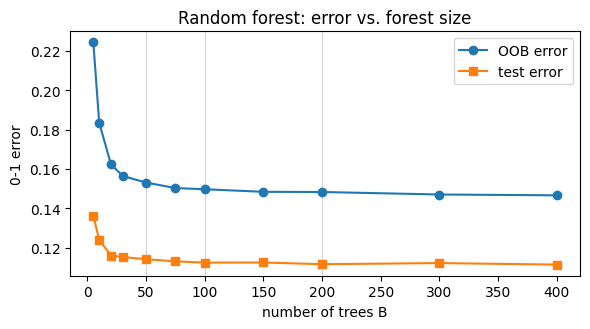

In [ ]:
rf_w = RandomForestClassifier(n_estimators=1, warm_start=True, oob_score=True, max_features="sqrt",
                              random_state=RNG_SEED, n_jobs=-1)
Bs = [5, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400]
oob_curve = []
for B in Bs:
    rf_w.set_params(n_estimators=B); rf_w.fit(X_train, y_train)
    oob_curve.append((B, 1 - rf_w.oob_score_, zero_one(rf_w, X_test, y_test)))
oob_curve = pd.DataFrame(oob_curve, columns=["B", "oob_err", "test_err"])
print(oob_curve.to_string(index=False))
RESULTS["rf_oob_curve"] = oob_curve.to_dict(orient="list")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(oob_curve.B, oob_curve.oob_err, "o-", label="OOB error")
ax.plot(oob_curve.B, oob_curve.test_err, "s-", label="test error")
for B in (50, 100, 200): ax.axvline(B, c="lightgray", lw=0.8, zorder=0)
ax.set_xlabel("number of trees B"); ax.set_ylabel("0-1 error"); ax.legend(); ax.set_title("Random forest: error vs. forest size")
plt.tight_layout(); plt.savefig("figures/rf_oob.pdf"); plt.savefig("figures/rf_oob.png", dpi=200); plt.show()

## 3.2.3 k-nearest neighbours

`sklearn.neighbors.KNeighborsClassifier` (Euclidean distance, uniform weights). The number of neighbours $k$ is chosen by
**contiguous 5-fold cross-validation** over $k \in \{1, 3, 5, \dots, 101\}$ (odd values avoid most voting ties in the
5-class problem). For comparison we also compute the curve under *shuffled* CV to show the effect of temporal leakage.

In [ ]:
ks = list(range(1, 102, 2))
def cv_curve(cv):
    out = []
    for k in ks:
        errs = 1 - cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=cv,
                                   scoring="accuracy", n_jobs=-1)
        out.append((k, errs.mean(), errs.std()))
    return pd.DataFrame(out, columns=["k", "cv_err", "cv_std"])

t = time.time()
knn_cv_contig = cv_curve(cv_contig)
knn_cv_shuffl = cv_curve(cv_shuffl)
print("done in %.0fs" % (time.time() - t))

best_k        = int(knn_cv_contig.loc[knn_cv_contig.cv_err.idxmin(), "k"])
best_k_shuffl = int(knn_cv_shuffl.loc[knn_cv_shuffl.cv_err.idxmin(), "k"])
print("best k (contiguous CV):", best_k, " CV err %.4f" % knn_cv_contig.cv_err.min())
print("best k (shuffled CV)  :", best_k_shuffl, " CV err %.4f" % knn_cv_shuffl.cv_err.min())

done in 344s
best k (contiguous CV): 101  CV err 0.1635
best k (shuffled CV)  : 79  CV err 0.1503


In [ ]:
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train, y_train)
knn_shuffl = KNeighborsClassifier(n_neighbors=best_k_shuffl).fit(X_train, y_train)

# NOTE: kNN "training error" with the training point included in its own neighbourhood is trivially optimistic
# (for k=1 it is exactly 0). We report it as requested, plus a leave-one-out version that excludes the point itself.
def loo_train_err(k):
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X_train)
    _, idx = nn.kneighbors(X_train)
    neigh = y_train[idx[:, 1:]]                       # drop the point itself
    votes = np.apply_along_axis(lambda r: np.bincount(r, minlength=K).argmax(), 1, neigh)
    return float(np.mean(votes != y_train))

knn_res = dict(best_k=best_k, cv_err=float(knn_cv_contig.cv_err.min()),
               train_err=zero_one(knn, X_train, y_train), test_err=zero_one(knn, X_test, y_test),
               train_err_loo=loo_train_err(best_k),
               shuffled_cv=dict(best_k=best_k_shuffl, cv_err=float(knn_cv_shuffl.cv_err.min()),
                                train_err=zero_one(knn_shuffl, X_train, y_train),
                                test_err=zero_one(knn_shuffl, X_test, y_test)))
RESULTS["knn"] = knn_res
RESULTS["knn_cv_contig"] = knn_cv_contig.to_dict(orient="list")
RESULTS["knn_cv_shuffled"] = knn_cv_shuffl.to_dict(orient="list")
print(json.dumps(knn_res, indent=2))

{
  "best_k": 101,
  "cv_err": 0.1635027264165627,
  "train_err": 0.14790653540505277,
  "test_err": 0.09704337817423207,
  "train_err_loo": 0.149833946151109,
  "shuffled_cv": {
    "best_k": 79,
    "cv_err": 0.15027873993037327,
    "train_err": 0.14692800379551654,
    "test_err": 0.09761887633983167
  }
}


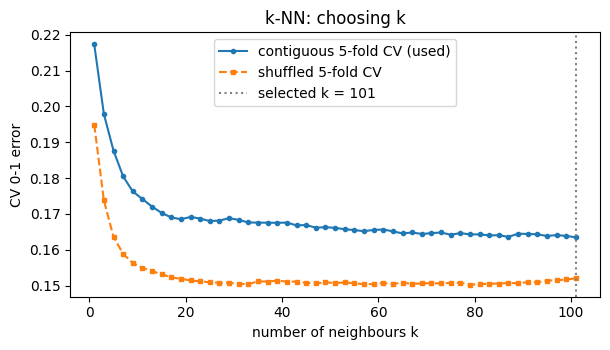

In [ ]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(knn_cv_contig.k, knn_cv_contig.cv_err, "o-", ms=3, label="contiguous 5-fold CV (used)")
ax.plot(knn_cv_shuffl.k, knn_cv_shuffl.cv_err, "s--", ms=3, label="shuffled 5-fold CV")
ax.axvline(best_k, c="gray", ls=":", label=f"selected k = {best_k}")
ax.set_xlabel("number of neighbours k"); ax.set_ylabel("CV 0-1 error"); ax.legend(); ax.set_title("k-NN: choosing k")
plt.tight_layout(); plt.savefig("figures/knn_cv.pdf"); plt.savefig("figures/knn_cv.png", dpi=200); plt.show()

## Summary of all classifiers and a per-class look at the errors

In [ ]:
rf_main = RandomForestClassifier(n_estimators=200, max_features="sqrt", oob_score=True,
                                 random_state=RNG_SEED, n_jobs=-1).fit(X_train, y_train)
summary = pd.DataFrame([
    ["Majority class",                 RESULTS["majority_baseline_train_err"], RESULTS["majority_baseline_test_err"], np.nan],
    ["Logistic regression (unreg.)",   lr_res["unregularised"]["train_err"], lr_res["unregularised"]["test_err"], np.nan],
    [f"Logistic regression (L2, C={best_C:.3g})", lr_res["l2_cv"]["train_err"], lr_res["l2_cv"]["test_err"], np.nan],
    ["Random forest, B=50",  rf_res[50]["train_err"],  rf_res[50]["test_err"],  rf_res[50]["oob_err"]],
    ["Random forest, B=100", rf_res[100]["train_err"], rf_res[100]["test_err"], rf_res[100]["oob_err"]],
    ["Random forest, B=200", rf_res[200]["train_err"], rf_res[200]["test_err"], rf_res[200]["oob_err"]],
    [f"kNN (k={best_k})", knn_res["train_err"], knn_res["test_err"], np.nan],
], columns=["model", "train_err", "test_err", "oob_err"])
print(summary.round(4).to_string(index=False))

# per-class recall on the TEST set, to see *where* the models fail
def per_class_recall(m):
    cm = confusion_matrix(y_test, m.predict(X_test), labels=range(K))
    return (cm.diagonal() / cm.sum(1))
rec = pd.DataFrame({"LogReg (L2)": per_class_recall(lr_reg), "RF (B=200)": per_class_recall(rf_main),
                    f"kNN (k={best_k})": per_class_recall(knn)}, index=[f"class {i}" for i in range(K)])
print("\nPer-class recall on test set:"); print(rec.round(3).to_string())
RESULTS["per_class_recall_test"] = {c: rec[c].tolist() for c in rec.columns}

                         model  train_err  test_err  oob_err
                Majority class     0.4791    0.4548      NaN
  Logistic regression (unreg.)     0.1495    0.0997      NaN
Logistic regression (L2, C=10)     0.1494    0.0997      NaN
           Random forest, B=50     0.0003    0.1141   0.1531
          Random forest, B=100     0.0000    0.1124   0.1497
          Random forest, B=200     0.0000    0.1116   0.1483
                   kNN (k=101)     0.1479    0.0970      NaN



Per-class recall on test set:
         LogReg (L2)  RF (B=200)  kNN (k=101)
class 0        0.981       0.983        0.984
class 1        0.526       0.512        0.535
class 2        0.880       0.873        0.878
class 3        0.638       0.552        0.646
class 4        0.792       0.714        0.803


In [ ]:
with open("results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("saved results.json")

saved results.json
